# MBARI YOLO Test from OceanCV
Revised June 4, 2026, by Sage Lichtenwalner

This notebook tries to recreate the exmaple from [OceanCV Ch 17](https://oceancv.org/book/FathomnetLocalizing_YOLO.html) by Ada Carter & Katie Bigham. It also tries a quick test to compare CPU vs. GPU processing.  The [ROV video](https://huggingface.co/datasets/OceanCV/ROVTransectCompressed) file is available on Hugging Face.

## Environment Setup

As of June 2026, the OOI Jupyter Hub Server appears to have the folowing GPU installed:
NVIDIA-SMI 550.163.01  Driver Version: 550.163.01  CUDA Version: 12.4

Apparently, this is not compatible with the latest version PyTorch (2.12), so we need to install an older version.  Based on [this reference](https://pytorch.org/get-started/previous-versions/)) it looks like pytorch 2.6 should work.  But in testing, it also seems like an older version of phython is also needed.  (The current version is 3.14.)

Run the following commands in the terminal to setup pytorch and ultralytics.  

```
conda create -n yolo python=3.10 -y
conda activate yolo
pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124
pip install ultralytics
conda install ipykernel -y
python -m ipykernel install --user --name yolo --display-name Yolo
jupyter kernelspec list
```

You can run the following line to see if a GPU is available.
```
python -c "import torch; print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"
```

To remove your environment, you can run the following commands
```
conda env remove yolo
jupyter kernelspec remove yolo
```

We will use ipykernel to setup the conda environment in JupyterHub so we can select it using the Kernel pulldown in the top-right of the Jupyter notebook window.  Note, it may take a few minutes for this new option to appear.


## Download Assets
Once you have your environment setup, you can download the following files.  This only needs to be done once.

The code below expects these files to be moved into `./yolo-test/`

In [1]:
# # Download ROV Video File
# !wget https://huggingface.co/datasets/OceanCV/ROVTransectCompressed/resolve/main/transect_compressed.mp4

In [2]:
# # Download FathomNet YOLO Model
# !wget https://huggingface.co/FathomNet/MBARI-315k-yolov8/resolve/main/mbari_315k_yolov8.pt

## Extract ROV Images
First, we need to extract image frames from the ROV video file.  This only needs to be done once.

In [3]:
# import os
# import cv2
# import numpy as np

# # Create a folder for the sampled frames
# subset_folder = "./yolo-test/frames"
# os.makedirs(subset_folder, exist_ok=True)

# # Input video file
# video_path = "./yolo-test/transect_compressed.mp4"

# # Sample frames from the video
# cap = cv2.VideoCapture(video_path)
# total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# frame_rate = int(cap.get(cv2.CAP_PROP_FPS))
# sample_rate = np.floor(total_frames/24) # Adjust this line to extract more or fewer frames

# frame_count = 0
# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break

#     if frame_count % sample_rate == 0:
#         frame_filename = os.path.join(subset_folder, f"frame_{frame_count}.jpg")
#         cv2.imwrite(frame_filename, frame)
#         print(frame_filename)

#     frame_count += 1

# cap.release()

# print(f"Sampled frames saved in folder: {subset_folder}")

## Run the prediction model

In [4]:
from ultralytics import YOLO
import time

We can check if GPU's are avaible using the following snippet from this [notebook](https://github.com/oceanobservatories-community/2025-Imaging-FlowCytobot-Workshop/blob/main/notebooks/miniPhytoCNN-inference-roi.ipynb).

In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    num_devs = torch.cuda.device_count()
    print(f"Number of GPUs: {num_devs}")
    dev_num = torch.cuda.current_device()
    gpu_type = torch.cuda.get_device_name(dev_num)
    print(f"Current GPU: {gpu_type}")
else:
    print("No GPU found, using CPU")

CUDA available: True
Number of GPUs: 4
Current GPU: NVIDIA L40S


In [6]:
# Image folder
subset_folder = "./yolo-test/frames"

# Load the MBARI 315k model
mbari_model = YOLO("./yolo-test/mbari_315k_yolov8.pt")

In [7]:
%%time
t0 = time.perf_counter()

# Run inference on the sampled frames with MBARI 315k
results = mbari_model.predict(
    source = subset_folder,
    conf = 0.10,
    iou = 0.5,
    imgsz = 1024,
    device = 'cpu', # cuda:0 or cpu
    # batch = 3,
    agnostic_nms = True,
    save = True,
    save_txt = True,
    save_conf = True,
)
t1 = time.perf_counter() - t0
print(f"CPU Processing Time: {t1:.4f}s")

image 1/25 /home/jovyan/yolo-test/frames/frame_0.jpg: 768x1024 1 Tromikosoma, 658.3ms


image 2/25 /home/jovyan/yolo-test/frames/frame_11436.jpg: 768x1024 1 Iosactis vagabunda, 1 Pennatulacea, 1 Synallactidae, 638.0ms


image 3/25 /home/jovyan/yolo-test/frames/frame_14295.jpg: 768x1024 1 Hyalonema, 1 Isopoda, 2 Paelopatides confundenss, 649.1ms


image 4/25 /home/jovyan/yolo-test/frames/frame_17154.jpg: 768x1024 1 Synallactidae, 599.3ms


image 5/25 /home/jovyan/yolo-test/frames/frame_20013.jpg: 768x1024 1 Coryphaenoides, 1 Paelopatides confundens, 597.4ms


...

image 24/25 /home/jovyan/yolo-test/frames/frame_68616.jpg: 768x1024 1 Paelopatides confundens, 621.2ms


image 25/25 /home/jovyan/yolo-test/frames/frame_8577.jpg: 768x1024 1 Macrouridae, 1 Paelopatides confundens, 1 Tromikosoma, 638.7ms


Speed: 2.0ms preprocess, 647.2ms inference, 1.8ms postprocess per image at shape (1, 3, 768, 1024)


Results saved to /home/jovyan/runs/detect/predict-10
21 labels saved to /home/jovyan/runs/detect/predict-10/labels


CPU Processing Time: 16.8054s
CPU times: user 2min 5s, sys: 6.23 s, total: 2min 11s
Wall time: 16.8 s


In [8]:
%%time
t0 = time.perf_counter()

# Run inference on the sampled frames with MBARI 315k
if torch.cuda.is_available():
  results = mbari_model.predict(
    source = subset_folder,
    conf = 0.10,
    iou = 0.5,
    imgsz = 1024,
    device = 'cuda', # cuda:0 or cpu
    # batch = 3,
    agnostic_nms = True,
    save = True,
    save_txt = True,
    save_conf = True,
  )
  t1 = time.perf_counter() - t0
  print(f"GPU Processing Time: {t1:.4f}s")


image 1/25 /home/jovyan/yolo-test/frames/frame_0.jpg: 768x1024 1 Tromikosoma, 50.5ms


image 2/25 /home/jovyan/yolo-test/frames/frame_11436.jpg: 768x1024 1 Iosactis vagabunda, 1 Pennatulacea, 1 Synallactidae, 18.1ms


image 3/25 /home/jovyan/yolo-test/frames/frame_14295.jpg: 768x1024 1 Hyalonema, 1 Isopoda, 2 Paelopatides confundenss, 34.0ms


image 4/25 /home/jovyan/yolo-test/frames/frame_17154.jpg: 768x1024 1 Synallactidae, 34.3ms


image 5/25 /home/jovyan/yolo-test/frames/frame_20013.jpg: 768x1024 1 Coryphaenoides, 1 Paelopatides confundens, 19.3ms


...

image 24/25 /home/jovyan/yolo-test/frames/frame_68616.jpg: 768x1024 1 Paelopatides confundens, 31.6ms


image 25/25 /home/jovyan/yolo-test/frames/frame_8577.jpg: 768x1024 1 Macrouridae, 1 Paelopatides confundens, 1 Tromikosoma, 26.6ms


Speed: 3.6ms preprocess, 31.0ms inference, 4.3ms postprocess per image at shape (1, 3, 768, 1024)


Results saved to /home/jovyan/runs/detect/predict-11
21 labels saved to /home/jovyan/runs/detect/predict-11/labels


GPU Processing Time: 2.6035s
CPU times: user 1.98 s, sys: 280 ms, total: 2.26 s
Wall time: 2.6 s


## View the Results
Let's take a quick look the prediction results for one frame

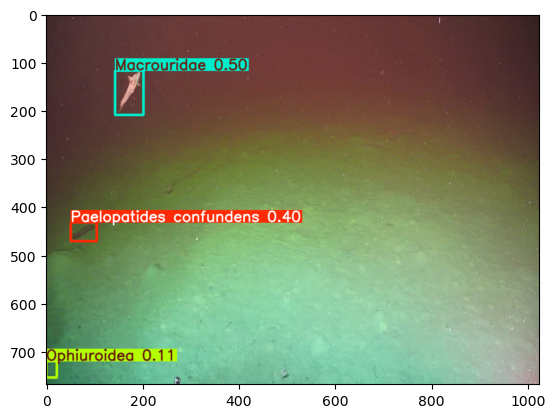

In [9]:
import matplotlib.pyplot as plt
plt.imshow(results[22].plot())

In [10]:
results[22].to_df()

name,class,confidence,box
str,i64,f64,struct[4]
"""Macrouridae""",267,0.50438,"{143.20387,117.00168,202.56026,209.5517}"
"""Paelopatides confundens""",320,0.39733,"{51.38312,432.38348,105.46765,471.7547}"
"""Ophiuroidea""",314,0.11154,"{0.0,720.34045,22.2431,754.33655}"


## Export the Results
If you would like to zip up and download all of the images and predictions, you can adjust and use the following script.  (Note, each time you run the prediction model, it will create a new directory, unless you manuall specifiy an output directory above.  So make sure to adjust the folder name below accordingly.)

In [11]:
# import zipfile
# import os
# import urllib.request

# def zip_folders_and_file(folder_paths, additional_file_url, output_filename):

#     additional_file_path = "config.yaml"
#     urllib.request.urlretrieve(additional_file_url, additional_file_path)

#     with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         for folder in folder_paths:
#             for root, _, files in os.walk(folder):
#                 for file in files:
#                     file_path = os.path.join(root, file)
#                     arcname = os.path.relpath(file_path, start=folder)
#                     zipf.write(file_path, arcname)
#         zipf.write(additional_file_path, os.path.basename(additional_file_path))

# folders_to_zip = ["./yolo-test/frames", "./runs/detect/predict/labels"]
# additional_file_url = "https://huggingface.co/FathomNet/MBARI-315k-yolov8/resolve/main/config.yaml?download=true"
# output_zip = "315k.zip"
# zip_folders_and_file(folders_to_zip, additional_file_url, output_zip)

## Summarize the Results

In [12]:
from pathlib import Path
import pandas as pd

rows = []
for result in results:
    image_name = Path(result.path).name if getattr(result, 'path', None) else 'unknown'
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        continue

    for i in range(len(boxes)):
        class_id = int(boxes.cls[i])
        rows.append({
            'image': image_name,
            'class_id': class_id,
            'class_name': result.names[class_id],
            'confidence': float(boxes.conf[i]),
            'x1': float(boxes.xyxy[i][0]),
            'y1': float(boxes.xyxy[i][1]),
            'x2': float(boxes.xyxy[i][2]),
            'y2': float(boxes.xyxy[i][3]),
        })

detection_df = pd.DataFrame(rows)

In [13]:
detection_df.head()

,image,class_id,class_name,confidence,x1,y1,x2,y2
0,frame_0.jpg,450,Tromikosoma,0.924625,500.479736,682.749512,571.983276,751.793945
1,frame_11436.jpg,231,Iosactis vagabunda,0.328567,369.309387,718.246338,400.737854,744.901367
2,frame_11436.jpg,428,Synallactidae,0.161742,848.852051,282.550903,878.955200,308.766113
3,frame_11436.jpg,340,Pennatulacea,0.121332,679.327148,159.756226,689.403809,208.643860
4,frame_14295.jpg,320,Paelopatides confundens,0.803059,749.843262,429.982025,815.720947,473.476410


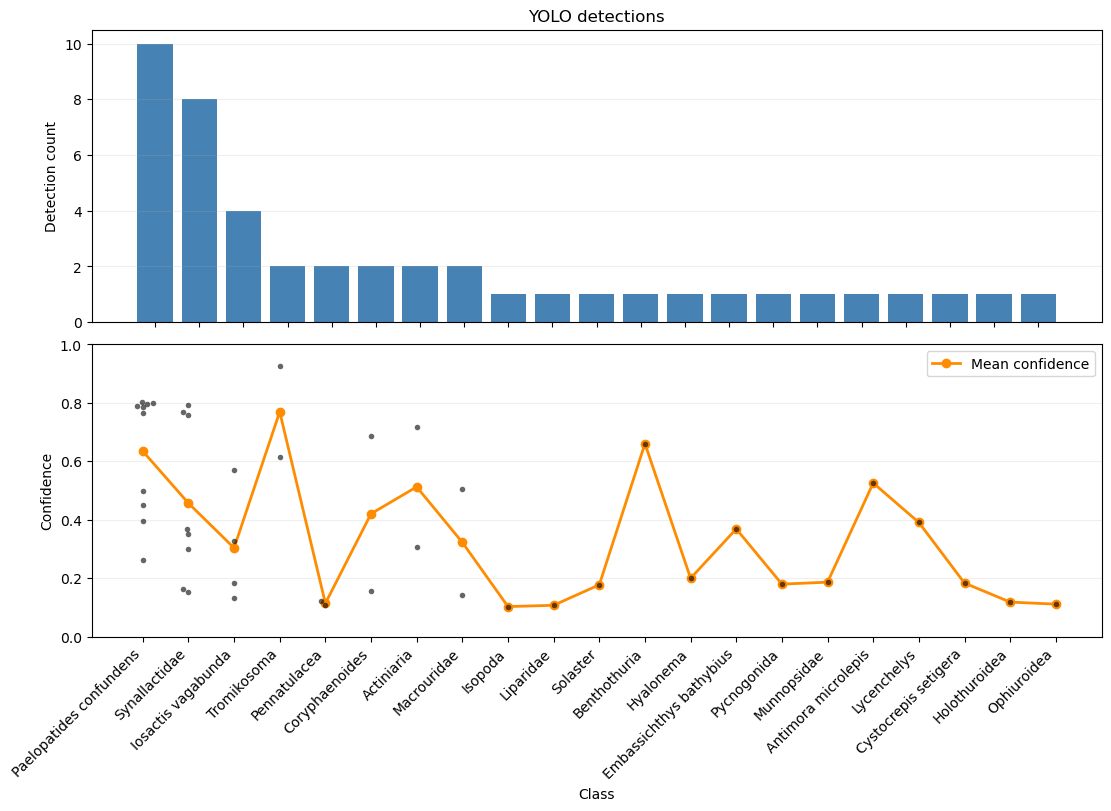

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_order = (
    detection_df["class_name"]
    .value_counts()
    .index
    .tolist()
)

count_df = (
    detection_df["class_name"]
    .value_counts()
    .reindex(class_order)
    .reset_index()
)
count_df.columns = ["class_name", "count"]

mean_conf = (
    detection_df.groupby("class_name")["confidence"]
    .mean()
    .reindex(class_order)
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=False,
    constrained_layout=True
)

# Top: counts
axes[0].bar(count_df["class_name"], count_df["count"], color="steelblue")
axes[0].set_ylabel("Detection count")
axes[0].set_title("YOLO detections")
axes[0].grid(axis="y", alpha=0.2)
axes[0].set_xticklabels([])
# axes[0].tick_params(axis='x', labelrotation=45)

# Bottom: beeswarm of confidence
sns.swarmplot(
    data=detection_df,
    x="class_name",
    y="confidence",
    order=class_order,
    ax=axes[1],
    size=4,
    color="black",
    alpha=0.6,
)

# Mean confidence line/markers
axes[1].plot(
    class_order,
    mean_conf.values,
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Mean confidence",
)

axes[1].set_ylabel("Confidence")
axes[1].set_xlabel("Class")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend()

plt.xticks(rotation=45, ha="right")
plt.show()